# Customer Retention Analysis

## Project Objective
The goal of this analysis is to understand customer churn behavior in a telecom company and identify factors influencing customer attrition.

### Key Business Questions
1. What are the key factors driving customer churn?
2. How does contract type and tenure affect churn rate?
3. Do monthly charges influence customer churn behavior?
4. Which services help retain customers the most?
5. What customer segments are most at risk of churn?

This analysis uses Python libraries such as Pandas, Matplotlib, and Seaborn to perform Exploratory Data Analysis (EDA) and generate actionable insights.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

The dataset contains customer demographic information, subscribed services, account information, and churn status.

We load the dataset and preview the first few records to understand its structure.

In [20]:
df = pd.read_csv("Telco_Cusomer_Churn.csv")

In [21]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Dataset Overview

Before performing analysis, it is important to understand:

- Number of rows and columns
- Data types
- Missing values

In [22]:
df.shape

(7043, 21)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [24]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [25]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Step 4: Data Cleaning

Data cleaning ensures that the dataset is ready for analysis.

Key tasks:
- Handle missing values
- Convert incorrect data types
- Prepare variables for analysis

The `TotalCharges` column sometimes contains blank values which prevents numerical analysis.

We convert it into numeric format and replace missing values with the median.

In [30]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

To simplify analysis, we convert the `Churn` column into numeric format.

Yes → 1  
No → 0

In [31]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

## Step 5: Customer Churn Rate

The churn rate represents the percentage of customers who stopped using the service.

Understanding churn rate helps companies measure customer retention performance.

In [32]:
churn_rate = df['Churn'].mean()*100
print("Customer Churn Rate:", churn_rate,"%")

Customer Churn Rate: 26.536987079369588 %


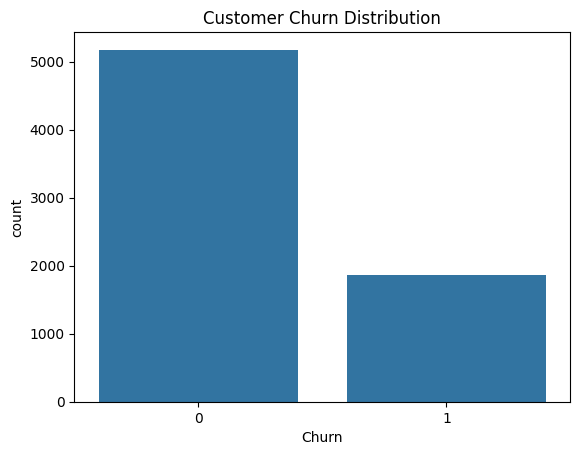

In [33]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

## Step 6: Contract Type Impact on Churn

Customers with shorter contract commitments may have a higher likelihood of leaving the company.

We analyze churn rate across different contract types:
- Month-to-month
- One year
- Two year

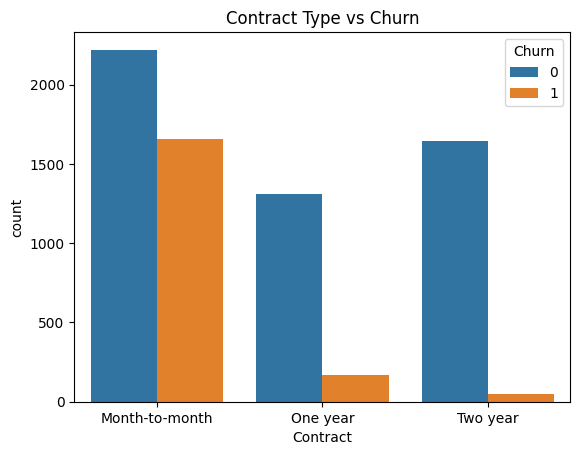

In [34]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

In [35]:
df.groupby('Contract')['Churn'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

## Step 7: Customer Tenure Analysis

Tenure represents how long a customer has been with the company.

New customers tend to churn more frequently than long-term customers.

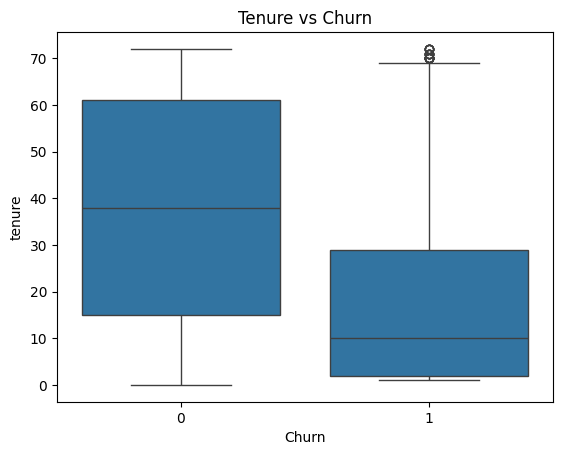

In [36]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

## Step 8: Monthly Charges Impact

Higher service costs may influence customers to leave.

We compare monthly charges between churned and retained customers.

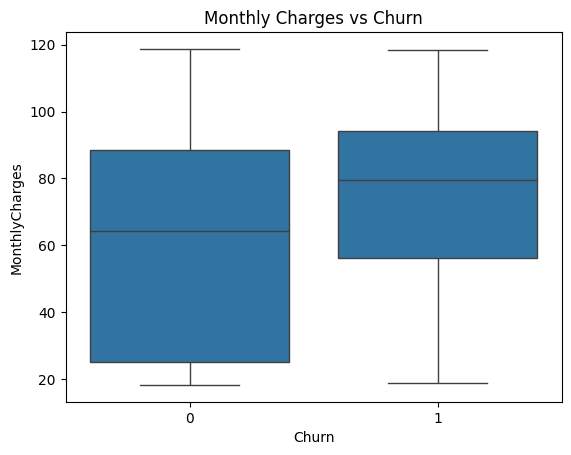

In [37]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

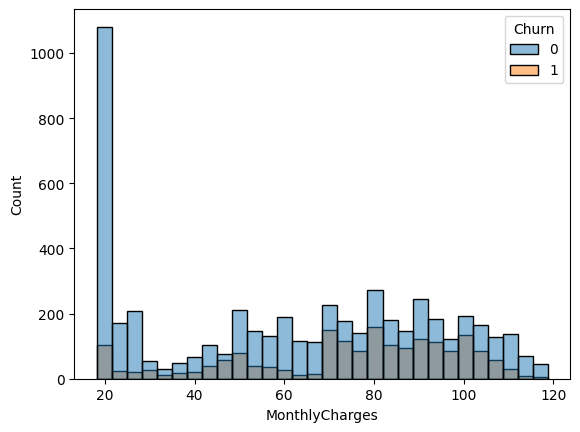

In [38]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30)
plt.show()

## Step 9: Service Usage Impact

We analyze whether additional services help retain customers.

Services analyzed:
- Online Security
- Tech Support
- Online Backup
- Device Protection

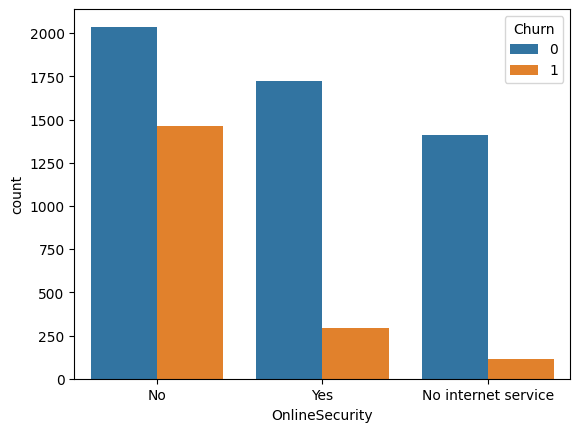

In [39]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.show()

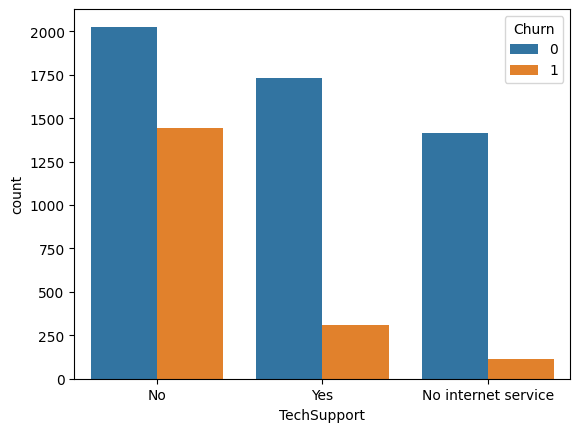

In [40]:
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.show()

## Step 10: Payment Method Impact

Payment method may influence churn behavior.

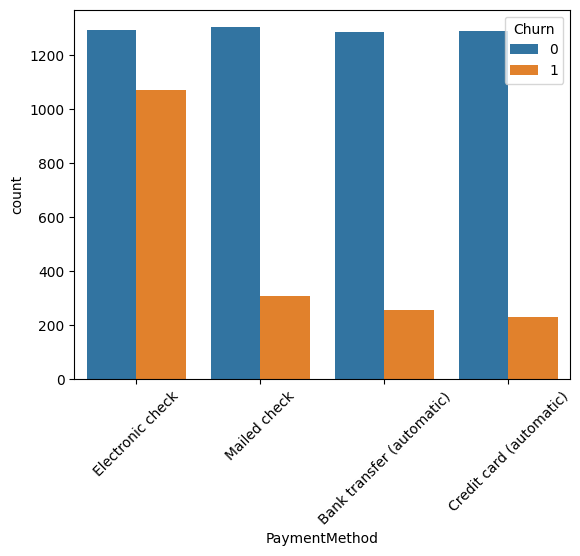

In [41]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

## Step 11: Identifying High Risk Customers

We define high-risk customers as those with:

- Month-to-month contracts
- Low tenure
- High monthly charges

In [42]:
high_risk = df[
(df['Contract'] == 'Month-to-month') &
(df['tenure'] < 12) &
(df['MonthlyCharges'] > df['MonthlyCharges'].median())
]

high_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,0
39,8168-UQWWF,Female,0,No,No,11,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),97.85,1105.40,1
47,7760-OYPDY,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.65,144.15,1


## Step 12: Customer Segmentation

We visualize churn clusters based on tenure and monthly charges.

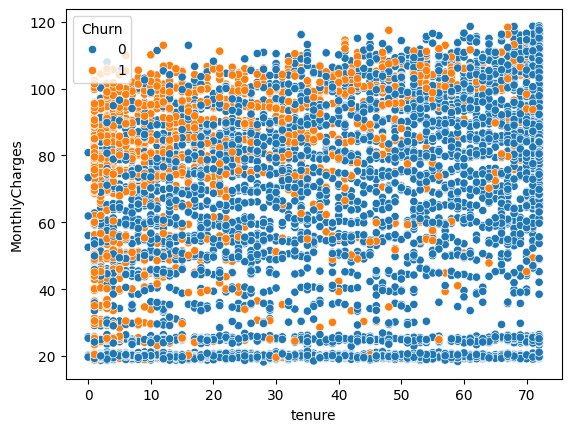

In [43]:
sns.scatterplot(
x='tenure',
y='MonthlyCharges',
hue='Churn',
data=df
)

plt.show()

# Key Findings

### Main Drivers of Churn
- Month-to-month contracts
- High monthly charges
- Low tenure customers
- Lack of tech support services

### High Risk Customers
Customers with:
- Short tenure
- High monthly charges
- Month-to-month contracts

### Business Recommendations
- Encourage customers to switch to long-term contracts
- Provide free tech support trials
- Offer loyalty discounts for new customers
- Bundle services to increase value perception